In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.read_csv("C:\BE sem8\BI\Loan.csv")
data = data.drop_duplicates()

print("Missing values before cleaning:\n", data.isnull().sum())

for col in data.columns:
    if data[col].dtype != 'object':
     
        data[col] = data[col].fillna(data[col].median())
    else:

        data[col] = data[col].fillna(data[col].mode()[0])


print("\nMissing values after cleaning:\n", data.isnull().sum())

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])


X = data.drop("LoanApproved", axis=1)
y = data["LoanApproved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(criterion="entropy", max_depth=4)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Missing values before cleaning:
 Age                       0
AnnualIncome              0
EmploymentStatus          0
EducationLevel            0
Experience                0
LoanAmount                0
LoanDuration              0
HomeOwnershipStatus       0
BankruptcyHistory         0
LoanPurpose               0
TotalDebtToIncomeRatio    0
LoanApproved              0
RiskScore                 0
dtype: int64

Missing values after cleaning:
 Age                       0
AnnualIncome              0
EmploymentStatus          0
EducationLevel            0
Experience                0
LoanAmount                0
LoanDuration              0
HomeOwnershipStatus       0
BankruptcyHistory         0
LoanPurpose               0
TotalDebtToIncomeRatio    0
LoanApproved              0
RiskScore                 0
dtype: int64

Accuracy: 0.97725

Confusion Matrix:
 [[2957   26]
 [  65  952]]


<>:7: SyntaxWarning: invalid escape sequence '\B'
<>:7: SyntaxWarning: invalid escape sequence '\B'
C:\Users\vidhi\AppData\Local\Temp\ipykernel_29564\917731883.py:7: SyntaxWarning: invalid escape sequence '\B'
  data = pd.read_csv("C:\BE sem8\BI\Loan.csv")


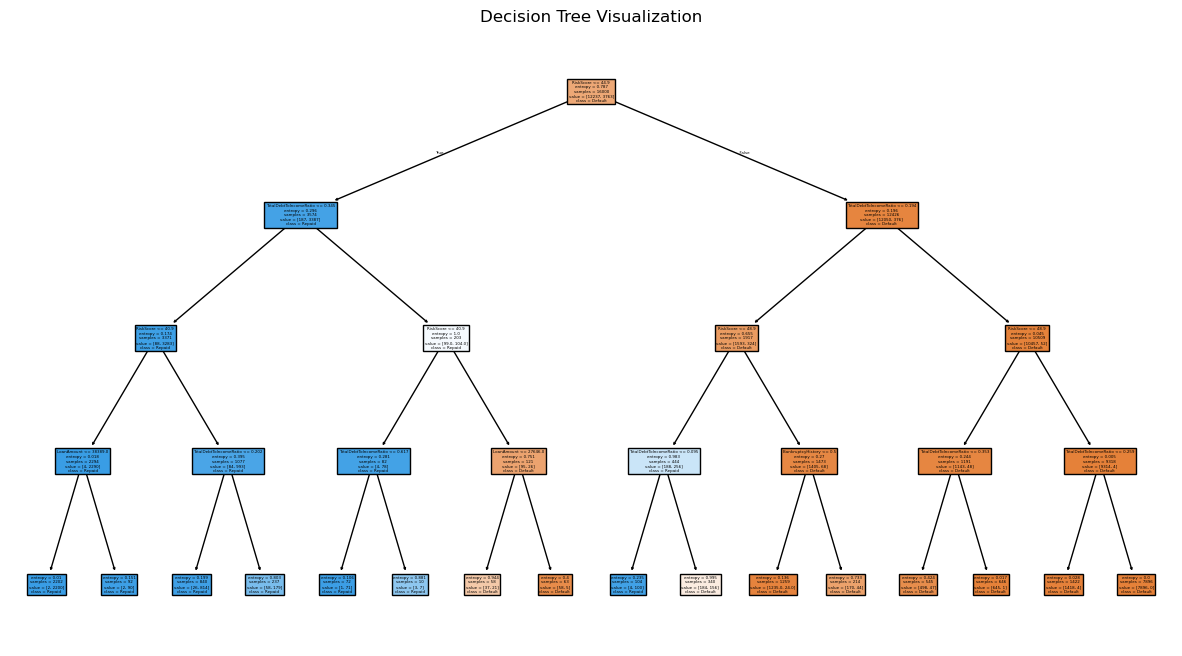

In [29]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Default", "Repaid"],
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()
